[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_12/MFM_ch12_seminar/MFM_ch12_seminar.ipynb)

# Modelling Financial Markets — Seminar 12: Options and the Volatility Surface

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: derivations checked on numbers (A1–A8); Part B: estimation and inference (B1–B8); Part C: open question.

> Quantlet `MFM_ch12_seminar`: student version of the Seminar 12 notebook. Solved exercises (A1, A2, A3, A5, B1, B2, B4) are shown with code and output; the proposed exercises (A4, A6, A7, A8, B3, B5, B6, B7, B8, C1, C2, C3) are not solved here (an empty code cell where they need code).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_12'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

In [ ]:
import os
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats, optimize, integrate
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

N, n = stats.norm.cdf, stats.norm.pdf

## Style and helpers

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Course colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
Teal     = '#17A2B8'

HERE = '.'
SEED = 42
BASE = {'S': 100.0, 'K': 100.0, 'T': 0.25, 'r': 0.04, 'sigma': 0.2}
HEDGE = {'S0': 100.0, 'K': 100.0, 'T': 0.25, 'r': 0.04, 'sigma': 0.2, 'mu': 0.08, 'nstep': 252, 'npath': 20000}


def save_fig(name):
    """Save the figure as PDF and transparent PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles, ncol=3, y=0.0):
    """One legend for a multi-panel figure, below the figure."""
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def nw_mean(x, lags):
    """Mean and Newey-West (HAC) standard error of a series."""
    x = np.asarray(x, float)
    m = sm.OLS(x, np.ones_like(x)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return float(m.params[0]), float(m.bse[0])


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, pd.Timestamp):
        return str(o)
    return o


import tempfile
# SAVE_TO_DRIVE = True (Colab cell above): charts and tables go to OUT_DIR in Google Drive; otherwise to a temporary folder
KEEP = bool(globals().get('SAVE_TO_DRIVE', False))
HERE = globals().get('OUT_DIR', '.') if KEEP else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE, also save it as PNG in OUT_DIR."""
    if KEEP:
        plt.savefig(os.path.join(HERE, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026: S&P 500 (S&P Dow Jones Indices), SPY open and close (State Street), VIX, VIX9D, VIX3M, VVIX (Cboe), Bitcoin.
- Bitcoin options: all listed contracts on Deribit, snapshot of 22 September 2026; DVOL, Deribit's 30-day implied-volatility index.
- Implied volatility in annualised %.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# course data: local copy when the notebook runs inside the repository, otherwise read online
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
SNAP_DIR = next((d for d in ('.', '../Quantlets/Ch_12', '../../Quantlets/Ch_12')
                 if os.path.exists(os.path.join(d, 'ch12_deribit_snapshot.csv'))), '.')
END = '2026-09-18'

# name -> (symbol, field, type)
SERIES = {
    'sp500': ('GSPC.INDX', 'close', 'index'),
    'spy':   ('SPY.US', 'adjusted_close', 'etf'),
    'btc':   ('BTC-USD.CC', 'close', 'crypto'),
    'vix':   ('VIX.INDX', 'close', 'vol'),
    'vix9d': ('VIX9D.INDX', 'close', 'vol'),
    'vix3m': ('VIX3M.INDX', 'close', 'vol'),
    'vvix':  ('VVIX.INDX', 'close', 'vol'),
}
DERIBIT = 'https://www.deribit.com/api/v2/public/'
SNAP_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_12/ch12_deribit_snapshot.csv'


def read_market(symbol):
    """Read the daily series of one symbol from the course data (local copy or online)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def load_close(name, start=None, end=END):
    """Daily price (or index level); except for crypto assets, weekdays only
    (days with an unchanged close are kept: they are real trading days)."""
    symbol, col, kind = SERIES[name]
    s = read_market(symbol)[col].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Log returns on the series' own calendar."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def spy_open_close(start=None, end=END):
    """Daily SPY open and close (unadjusted prices: the same-day ratio does not depend on adjustments)."""
    d = read_market('SPY.US').loc[start:end, ['open', 'close']]
    d = d[(d > 0).all(axis=1)]
    return d[d.index.dayofweek < 5]


def _get(method, **params):
    url = DERIBIT + method + '?' + '&'.join(f'{k}={v}' for k, v in params.items())
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    return json.load(urllib.request.urlopen(req, timeout=60))['result']


def deribit_chain(path=None, refresh=False):
    """BTC option chain (mark prices, implied volatilities) at the snapshot time."""
    path = path or os.path.join(SNAP_DIR, 'ch12_deribit_snapshot.csv')
    if not refresh:
        for src in (path, SNAP_RAW):
            try:
                return pd.read_csv(src, parse_dates=['snapshot_utc', 'expiry'])
            except Exception:
                pass
    rows = _get('get_book_summary_by_currency', currency='BTC', kind='option')
    t0 = pd.Timestamp.now(tz='UTC').floor('min').tz_localize(None)
    out = []
    for x in rows:
        _, exp, strike, cp = x['instrument_name'].split('-')
        out.append(dict(snapshot_utc=t0, instrument=x['instrument_name'],
                        expiry=pd.to_datetime(exp, format='%d%b%y') + pd.Timedelta(hours=8),
                        strike=float(strike), type='call' if cp == 'C' else 'put',
                        mark_iv=x['mark_iv'], mark_price=x['mark_price'], bid=x['bid_price'], ask=x['ask_price'],
                        forward=x['underlying_price'], index=x['estimated_delivery_price'],
                        open_interest=x['open_interest'], volume_usd=x['volume_usd']))
    d = pd.DataFrame(out).sort_values(['expiry', 'strike', 'type']).reset_index(drop=True)
    d.to_csv(path, index=False)
    return d


def dvol_history(start='2021-03-24', end=END):
    """DVOL index (30-day implied volatility of BTC options, annualised, in %), daily values."""
    t1 = int(pd.Timestamp(end).tz_localize('UTC').timestamp() * 1000) + 86_400_000
    t0 = int(pd.Timestamp(start).tz_localize('UTC').timestamp() * 1000)
    data = []
    while True:
        r = _get('get_volatility_index_data', currency='BTC', start_timestamp=t0, end_timestamp=t1, resolution='1D')
        data += r['data']
        if not r.get('continuation') or r['continuation'] <= t0:
            break
        t1 = r['continuation']
    d = pd.DataFrame(data, columns=['t', 'open', 'high', 'low', 'close']).drop_duplicates('t')
    d.index = pd.to_datetime(d['t'], unit='ms').dt.normalize()
    return d.sort_index()['close'].loc[start:end].rename('dvol')

## Option pricing tools

- `bs_price`, `bs_greeks`: Black–Scholes and the Greeks; `implied_vol`, `newton_iv`: implied volatility.
- `merton_price`, `heston_price`: jump and stochastic-volatility models.
- `svi_w`, `svi_fit`: SVI smile; `delta_hedge`: discrete delta hedging.

In [ ]:
def bs_price(S, K, T, r, sigma, kind='call', q=0.0):
    """Black-Scholes price of a European option."""
    S, K, T, sigma = map(np.asarray, (S, K, T, sigma))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == 'call':
        return S * np.exp(-q * T) * N(d1) - K * np.exp(-r * T) * N(d2)
    return K * np.exp(-r * T) * N(-d2) - S * np.exp(-q * T) * N(-d1)


def bs_greeks(S, K, T, r, sigma, kind='call', q=0.0):
    """Delta, gamma, vega (per volatility point), theta (per calendar day), rho; plus d1, d2."""
    S, K, T, sigma = map(np.asarray, (S, K, T, sigma))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    gamma = np.exp(-q * T) * n(d1) / (S * sigma * np.sqrt(T))
    vega = S * np.exp(-q * T) * n(d1) * np.sqrt(T) / 100
    common = -S * np.exp(-q * T) * n(d1) * sigma / (2 * np.sqrt(T))
    if kind == 'call':
        delta = np.exp(-q * T) * N(d1)
        theta = common - r * K * np.exp(-r * T) * N(d2) + q * S * np.exp(-q * T) * N(d1)
        rho = K * T * np.exp(-r * T) * N(d2) / 100
    else:
        delta = -np.exp(-q * T) * N(-d1)
        theta = common + r * K * np.exp(-r * T) * N(-d2) - q * S * np.exp(-q * T) * N(-d1)
        rho = -K * T * np.exp(-r * T) * N(-d2) / 100
    return dict(d1=d1, d2=d2, delta=delta, gamma=gamma, vega=vega, theta=theta / 365, rho=rho)


def implied_vol(price, S, K, T, r, kind='call', q=0.0, lo=1e-4, hi=5.0):
    """Implied volatility: the unique solution of BS(sigma) = price (vega > 0)."""
    f = lambda s: bs_price(S, K, T, r, s, kind, q) - price
    if f(lo) > 0 or f(hi) < 0:
        return np.nan
    return optimize.brentq(f, lo, hi, xtol=1e-10)


def newton_iv(price, S, K, T, r, sigma0=0.2, kind='call', steps=4):
    """Newton steps: sigma_{k+1} = sigma_k - (BS(sigma_k) - price) / vega(sigma_k)."""
    out, s = [], sigma0
    for _ in range(steps):
        p = float(bs_price(S, K, T, r, s, kind))
        v = float(bs_greeks(S, K, T, r, s, kind)['vega']) * 100
        s_new = s - (p - price) / v
        out.append(dict(sigma=s, price=p, vega=v, sigma_next=s_new))
        s = s_new
    return out


def merton_price(S, K, T, r, sigma, lam, mu_j, sig_j, kind='call', nmax=60):
    """Merton (1976): log-normal jumps ln(1+J) ~ N(mu_j, sig_j^2), intensity lam; Poisson series of BS prices."""
    kappa = np.exp(mu_j + 0.5 * sig_j ** 2) - 1
    lam2 = lam * (1 + kappa)
    tot = 0.0
    for k in range(nmax):
        s_k = np.sqrt(sigma ** 2 + k * sig_j ** 2 / T)
        r_k = r - lam * kappa + k * np.log(1 + kappa) / T
        w = stats.poisson.pmf(k, lam2 * T)
        tot = tot + w * bs_price(S, K, T, r_k, s_k, kind)
    return tot


def heston_price(S, K, T, r, v0, kappa, theta, xi, rho, kind='call'):
    """Heston (1993): call price by the Lewis (2001) formula, with the characteristic function of ln(S_T/F) (stable form)."""
    def phi(u):
        d = np.sqrt((rho * xi * 1j * u - kappa) ** 2 + xi ** 2 * (1j * u + u ** 2))
        g = (kappa - rho * xi * 1j * u - d) / (kappa - rho * xi * 1j * u + d)
        e = np.exp(-d * T)
        C = kappa * theta / xi ** 2 * ((kappa - rho * xi * 1j * u - d) * T - 2 * np.log((1 - g * e) / (1 - g)))
        D = (kappa - rho * xi * 1j * u - d) / xi ** 2 * (1 - e) / (1 - g * e)
        return np.exp(C + D * v0)
    x = np.log(S / K) + r * T
    f = lambda u: (np.exp(1j * u * x) * phi(u - 0.5j)).real / (u ** 2 + 0.25)
    call = S - np.sqrt(S * K) * np.exp(-r * T / 2) / np.pi * integrate.quad(f, 0, 200, limit=500, epsabs=1e-12)[0]
    return call if kind == 'call' else call - S + K * np.exp(-r * T)


def svi_w(k, a, b, rho, m, s):
    """SVI (Gatheral): total implied variance w(k) = a + b (rho (k - m) + sqrt((k - m)^2 + s^2)), k = ln(K/F)."""
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s ** 2))


def svi_fit(k, w, weights=None):
    """SVI fit by (weighted) least squares, with constraints b >= 0, |rho| < 1, s > 0."""
    k, w = np.asarray(k), np.asarray(w)
    wt = np.ones_like(w) if weights is None else np.asarray(weights)
    def loss(p):
        return np.sum(wt * (svi_w(k, *p) - w) ** 2)
    best = None
    for rho0 in (-0.5, 0.0, 0.3):
        for s0 in (0.05, 0.2):
            x0 = [max(w.min() * 0.5, 1e-4), 0.1, rho0, 0.0, s0]
            res = optimize.minimize(loss, x0, method='L-BFGS-B',
                                    bounds=[(-1, 5), (1e-6, 10), (-0.999, 0.999), (-2, 2), (1e-4, 3)])
            if best is None or res.fun < best.fun:
                best = res
    a, b, rho, m, s = best.x
    return dict(a=a, b=b, rho=rho, m=m, s=s, rmse=np.sqrt(best.fun / wt.sum()),
                wmin=a + b * s * np.sqrt(1 - rho ** 2))


def delta_hedge(paths, K, T, r, sigma_imp, n_rebal, kind='call'):
    """Sell an option at BS(sigma_imp) and delta-hedge it n_rebal times until expiry.
    paths: price matrix (n_paths, n_steps+1) on a uniform grid; n_steps divisible by n_rebal.
    Returns the hedging error at expiry (hedge portfolio value minus the option pay-off)."""
    npath, nstep = paths.shape[0], paths.shape[1] - 1
    every = nstep // n_rebal
    dt = T / nstep
    S0 = paths[:, 0]
    V0 = bs_price(S0, K, T, r, sigma_imp, kind)
    delta = bs_greeks(S0, K, T, r, sigma_imp, kind)['delta']
    cash = V0 - delta * S0
    for i in range(1, nstep + 1):
        cash = cash * np.exp(r * dt)
        if i % every == 0 and i < nstep:
            tau = T - i * dt
            d_new = bs_greeks(paths[:, i], K, tau, r, sigma_imp, kind)['delta']
            cash -= (d_new - delta) * paths[:, i]
            delta = d_new
    ST = paths[:, -1]
    payoff = np.maximum(ST - K, 0) if kind == 'call' else np.maximum(K - ST, 0)
    return cash + delta * ST - payoff

## Seminar functions

- Simulated paths, the Bitcoin surface and the variance risk premium of the S&P 500 (the seminar's helper code).

In [ ]:
B_BOOT = 1000
A8_K = [80, 85, 90, 95, 100, 105, 110, 115, 120]
BFLY_EXPIRY = '2026-10-30 08:00:00'


def gbm_paths(S0, mu, sigma, T, nstep, npath, seed=SEED):
    rng = np.random.default_rng(seed)
    dt = T / nstep
    z = rng.standard_normal((npath, nstep))
    x = np.cumsum((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((npath, 1)), x]))


def btc_surface():
    """SVI fit for every expiry of the BTC chain (quoted OTM options, at least 2 days to expiry)."""
    c = deribit_chain()
    t0 = c['snapshot_utc'].iloc[0]
    c['T'] = (c['expiry'] - t0).dt.total_seconds() / (365 * 86400)
    c = c[(c['T'] >= 2 / 365) & (c['mark_iv'] > 0) & (c['bid'] > 0)]
    c = c[((c['type'] == 'put') & (c['strike'] < c['forward'])) | ((c['type'] == 'call') & (c['strike'] >= c['forward']))].copy()
    c['k'] = np.log(c['strike'] / c['forward'])
    c['w'] = (c['mark_iv'] / 100) ** 2 * c['T']
    c = c[c['k'].abs() < 1.2]
    fits = {}
    for e, g in c.groupby('expiry'):
        if len(g) < 7:
            continue
        f = svi_fit(g['k'].values, g['w'].values)
        T = g['T'].iloc[0]
        iv = lambda k: 100 * np.sqrt(svi_w(k, f['a'], f['b'], f['rho'], f['m'], f['s']) / T)
        fits[e] = dict(T=T, days=T * 365, F=float(g['forward'].iloc[0]), n=int(len(g)), atm=float(iv(0.0)),
                       rr=float(iv(0.15) - iv(-0.15)), wing_dn=float(iv(-0.3)), wing_up=float(iv(0.3)),
                       rmse_iv=float(np.sqrt(np.mean((iv(g['k'].values) - g['mark_iv'].values) ** 2))), **f)
    tab = pd.DataFrame(fits).T
    tab.index.name = 'expiry'
    tab.to_csv(os.path.join(HERE, 'ch12_btc_svi.csv'))
    return c, tab, t0


def pick(tab, days):
    """Expiry closest to a given number of days."""
    return (tab['days'] - days).abs().astype(float).idxmin()


def vrp_sp500():
    """Variance risk premium: VIX^2 minus realised variance over the next 21 trading days."""
    px = pd.concat([load_close('sp500'), load_close('vix')], axis=1, join='inner').dropna()
    r = np.log(px['sp500']).diff()
    rv = 252 / 21 * (r ** 2).rolling(21).sum().shift(-21) * 1e4       # annualised (%)^2
    d = pd.DataFrame({'vix': px['vix'], 'iv2': px['vix'] ** 2, 'rv': rv, 'rv_past': rv.shift(21)}).dropna()
    d['vrp'] = d['iv2'] - d['rv']
    d['vrp_vol'] = d['vix'] - np.sqrt(d['rv'])
    return d


def qlike(rv, f):
    return rv / f - np.log(rv / f) - 1


def hac_se(u, lags):
    """HAC (Newey-West, Bartlett) standard error of the mean of a series."""
    u = np.asarray(u, float)
    return nw_mean(u, lags)[1]

## Part A — pen and paper

### A3. Bounds and convexity in the strike [Solved]

- Derive $\max(S - Ke^{-r\tau}, 0) \le C \le S$ and the convexity of $C(K)$; check butterflies on the Deribit chain (expiry 30 Oct 2026).

In [7]:
# Solution
def a1_butterfly(h=1000.0, K0=85000.0):
    """Convexity in K on the Bitcoin chain: butterfly C(K-h) - 2C(K) + C(K+h) from mark prices in USD (premium in BTC
    x index S, Deribit convention) and the executable cost (wings at the ask, body at the bid); density
    q(K) ~ e^{r tau} butterfly / h^2, with e^{r tau} = F/S (rate implied by the Deribit forward)."""
    c = deribit_chain()
    g = c[(c['expiry'] == pd.Timestamp(BFLY_EXPIRY)) & (c['type'] == 'call')].set_index('strike').sort_index()
    F, S = float(g['forward'].iloc[0]), float(g['index'].iloc[0])
    usd = lambda col: g[col] * S
    m, b, a = usd('mark_price'), usd('bid'), usd('ask')
    out = dict(F=F, S=S, growth=F / S, h=h, K=K0, Cm=float(m[K0 - h]), C0=float(m[K0]), Cp=float(m[K0 + h]),
               bid0=float(b[K0]), askm=float(a[K0 - h]), askp=float(a[K0 + h]))
    out['bf_mark'] = out['Cm'] - 2 * out['C0'] + out['Cp']
    out['bf_exec'] = out['askm'] - 2 * out['bid0'] + out['askp']
    out['q'] = F / S * out['bf_mark'] / h ** 2
    out['mass'] = F / S * out['bf_mark'] / h                 # E^Q[(h - |S_T - K|)^+]/h: triangle-weighted mass ~ h q(K)
    out['p_int'] = 2 * h * out['q']                           # ~ P(K - h < S_T < K + h), unweighted
    # all equally spaced strike triplets in the chain of this expiry
    Ks = list(g.index)
    n_tr = n_neg_mark = n_neg_exec = 0
    neg, spr = [], []
    for i in range(1, len(Ks) - 1):
        for j in range(i + 1, len(Ks)):
            hh = Ks[j] - Ks[i]
            if Ks[i] - hh in g.index:
                n_tr += 1
                bm = m[Ks[i] - hh] - 2 * m[Ks[i]] + m[Ks[j]]
                n_neg_mark += int(bm < 0)
                if bm < 0:
                    neg.append(float(bm)); spr.append(float(a[Ks[i]] - b[Ks[i]]))
                if np.isfinite(a[Ks[i] - hh]) and np.isfinite(b[Ks[i]]) and np.isfinite(a[Ks[j]]) and b[Ks[i]] > 0:
                    n_neg_exec += int(a[Ks[i] - hh] - 2 * b[Ks[i]] + a[Ks[j]] < 0)
    out.update(n_triples=n_tr, n_neg_mark=n_neg_mark, n_neg_exec=n_neg_exec, worst_neg=float(min(neg)) if neg else 0.0,
               spread_neg=float(np.median(spr)) if spr else 0.0)
    return out


a1_butterfly()

{'F': 85741.86,
 'S': 85265.19,
 'growth': 1.005590440835234,
 'h': 1000.0,
 'K': 85000.0,
 'Cm': 4957.2567556632,
 'C0': 4414.3843754079,
 'Cp': 3922.983179748,
 'bid0': 4391.157285,
 'askm': 5030.64621,
 'askp': 3964.831335,
 'bf_mark': 51.4711845954007,
 'bf_exec': 213.16297499999928,
 'q': 5.1758931207600696e-05,
 'mass': 0.051758931207600695,
 'p_int': 0.10351786241520139,
 'n_triples': 732,
 'n_neg_mark': 7,
 'n_neg_exec': 0,
 'worst_neg': -11.8024075998037,
 'spread_neg': 255.79557000000204}

### A4. Parity as a regression: the implied forward [Proposed]

- Regress $C - P$ on $K$ across strikes; estimate $D$ and $F$ with a delta-method standard error. Model: A3.

In [ ]:
# Your code here


### A5. The Black–Scholes equation and the hedging P&L [Solved]

- Derivation on the slides; numerical check: daily P&L $\frac{1}{2}\Gamma S^2(\sigma_{imp}^2 - \sigma_{real}^2)/252$ for the option of A1 with $\sigma_{real} = 30\%$.

In [9]:
# Solution
def a5_bs():
    """Black-Scholes step by step: S = K = 100, T = 6 months, r = 3%, sigma = 25%."""
    S, K, T, r, s = 100.0, 100.0, 0.5, 0.03, 0.25
    g = bs_greeks(S, K, T, r, s)
    return dict(d1=float(g['d1']), d2=float(g['d2']), Nd1=float(stats.norm.cdf(g['d1'])), Nd2=float(stats.norm.cdf(g['d2'])),
                pvk=K * np.exp(-r * T), C=float(bs_price(S, K, T, r, s)), P=float(bs_price(S, K, T, r, s, 'put')),
                delta=float(g['delta']), gamma=float(g['gamma']), vega=float(g['vega']), theta=float(g['theta']),
                nd1=float(stats.norm.pdf(g['d1'])))


g5 = a5_bs()
0.5 * g5['gamma'] * 100 ** 2 * (0.25 ** 2 - 0.30 ** 2) / 252

-0.012130259194528667

### A6. The binomial tree converges to Black–Scholes [Proposed]

- $N(C_N - C_{BS})$ for even and odd $N$; order of the error and its oscillation. Model: A5.

In [ ]:
# Your code here


### A1. One identity for all the Greeks [Solved]

- Prove $S\varphi(d_1) = Ke^{-r\tau}\varphi(d_2)$, derive vega $= \Gamma S^2\sigma\tau$; check with $S = K = 100$, six months, $r = 3\%$, $\sigma = 25\%$.

In [11]:
# Solution
g5 = a5_bs()
print(100 * g5['nd1'], g5['pvk'] * stats.norm.pdf(g5['d2']))
print(100 * g5['nd1'] * np.sqrt(0.5), g5['gamma'] * 100 ** 2 * 0.25 * 0.5)

39.30003473760774 39.30003473760773
27.789321063829313 27.789321063829313


### A7. A delta-gamma hedge [Proposed]

- 1,000 sold calls of A1; hedge with a call $K = 110$ and the stock. Model: A1.

In [ ]:
# Your code here


### A2. Implied volatility: existence, uniqueness, starting value [Solved]

- Call $S = K = 100$, three months, $r = 2\%$, price 4.50: at-the-money approximation, then Newton from 20%.

In [13]:
# Solution
def a7_newton():
    """Implied volatility by Newton: call S = K = 100, T = 3 months, r = 2%, market price 4.50, sigma_0 = 20%."""
    steps = newton_iv(4.50, 100.0, 100.0, 0.25, 0.02, sigma0=0.20, steps=3)
    return dict(steps=steps, exact=implied_vol(4.50, 100.0, 100.0, 0.25, 0.02))


pvk = 100 * np.exp(-0.02 * 0.25)
print(4.50 * np.sqrt(2 * np.pi) / 50, (4.50 - (100 - pvk) / 2) * np.sqrt(2 * np.pi) / 50)
r = a7_newton()
print(pd.DataFrame(r['steps']).round(6))
r['exact']

0.22559654471679003 0.21309468404085724
      sigma     price       vega  sigma_next
0  0.200000  4.232160  19.847627    0.213495
1  0.213495  4.499998  19.847204    0.213495
2  0.213495  4.500000  19.847204    0.213495


0.21349492122828795

### A8. The variance-swap strike and its estimation error [Proposed]

- Log-normal benchmark ($\sigma = 20\%$, 90 days): Cboe sum with $\Delta K = 5$ on $[80, 120]$ vs dense integrals; discretisation and truncation. Model: A3.

In [ ]:
# Your code here


### B1. Hedging error and rebalancing frequency [Solved]

- 10,000 paths; $N = 6, \dots, 252$ rebalancings; bootstrap intervals and the log-log slope.
- Interpretation:
  - is the slope consistent with $-1/2$?
  - how often must a dealer rebalance?

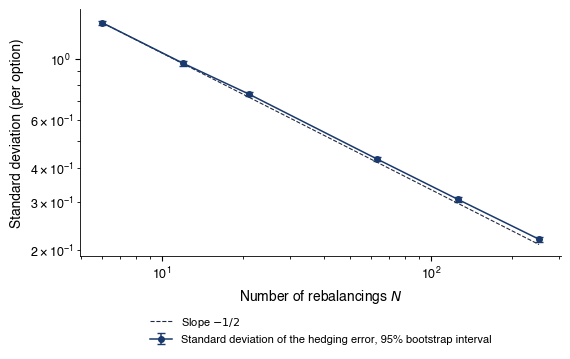

{'prem': 4.485236409022086,
 'sd': {6: 1.3561114441807223,
  12: 0.9630296813486001,
  21: 0.7441251928683007,
  63: 0.4301379906209573,
  126: 0.3059805862658455,
  252: 0.21876310249452238},
 'ci': {6: (1.3312248262461828, 1.3814845678931342),
  12: (0.9453436758236601, 0.9828037011914749),
  21: (0.7307205864922295, 0.7582203370962783),
  63: (0.4216674626228608, 0.4380982311607113),
  126: (0.3003316101381488, 0.3115477077930295),
  252: (0.2145679028364728, 0.22296632255053228)},
 'slope': -0.4886660065637433,
 'slope_lo': -0.49578489854734725,
 'slope_hi': -0.48233299994935763,
 'ratio_63_252': 1.966227328631562}

In [15]:
# Solution
def b1_hedge_boot():
    """Hedging error (standard deviation) for N rebalancings, with a 95% bootstrap interval; log-log slope."""
    rng = np.random.default_rng(SEED)
    S0, K, T, r, s, mu = 100.0, 100.0, 0.25, 0.04, 0.20, 0.08
    paths = gbm_paths(S0, mu, s, T, 252, 10000, seed=SEED)
    prem = float(bs_price(S0, K, T, r, s))
    Ns = [6, 12, 21, 63, 126, 252]
    E = {n: delta_hedge(paths, K, T, r, s, n) for n in Ns}
    idx = rng.integers(0, paths.shape[0], size=(B_BOOT, paths.shape[0]))
    sd = {n: float(E[n].std()) for n in Ns}
    boot = {n: np.array([E[n][i].std() for i in idx]) for n in Ns}
    ci = {n: (float(np.quantile(boot[n], 0.025)), float(np.quantile(boot[n], 0.975))) for n in Ns}
    x = np.log(Ns)
    slope = float(np.polyfit(x, np.log([sd[n] for n in Ns]), 1)[0])
    bs_slopes = np.array([np.polyfit(x, np.log([boot[n][b] for n in Ns]), 1)[0] for b in range(B_BOOT)])
    fig, ax = plt.subplots(figsize=(6.2, 3.2))
    y = np.array([sd[n] for n in Ns]); lo = np.array([ci[n][0] for n in Ns]); hi = np.array([ci[n][1] for n in Ns])
    ax.errorbar(Ns, y, yerr=[y - lo, hi - y], fmt='o-', color=MainBlue, ms=4, capsize=3,
                label='Standard deviation of the hedging error, 95% bootstrap interval')
    ax.plot(Ns, y[0] * np.sqrt(Ns[0] / np.array(Ns)), color=Gray, lw=0.8, ls='--', label='Slope $-1/2$')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Number of rebalancings $N$'); ax.set_ylabel('Standard deviation (per option)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch12_sem_hedge')
    return dict(prem=prem, sd=sd, ci=ci, slope=slope, slope_lo=float(np.quantile(bs_slopes, 0.025)),
                slope_hi=float(np.quantile(bs_slopes, 0.975)), ratio_63_252=sd[63] / sd[252])


b1_hedge_boot()

### B5. Delta-hedged S&P 500 options, 1990–2026 [Proposed]

- Mean monthly P&L with Newey–West errors and a block bootstrap; the five worst months. Model: B1, B2.
- Interpretation: why can a strategy with a high $t$-statistic still be dangerous?

In [ ]:
# Your code here


### B4. An SVI smile for Bitcoin [Solved]

- Expiry closest to 30 days; SVI fit, pairs bootstrap for the ATM volatility and the skew, no-butterfly check.
- Interpretation: is the skew significantly different from 0?

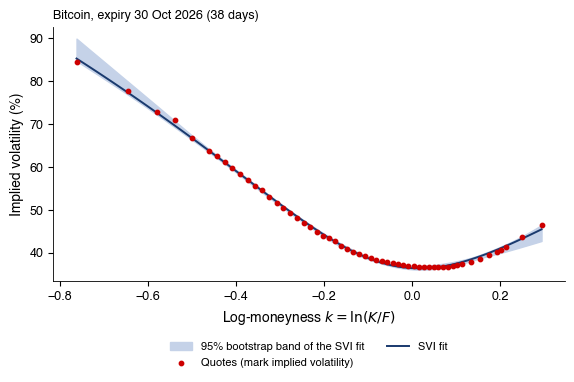

{'expiry': '2026-10-30',
 'days': 38.00625,
 'n': 56,
 'a': -0.020406852153552174,
 'b': 0.10161644378352698,
 'rho': -0.26151153557361,
 'm': -0.07867242402696553,
 's': 0.3481761906838664,
 'rmse': 0.42315407568949,
 'atm': 36.37165153045735,
 'rr': -2.107776573903692,
 'atm_lo': 36.10210225067656,
 'atm_hi': 36.869008723478856,
 'rr_lo': -2.7251376979681083,
 'rr_hi': -1.5210193507293,
 'gmin': 0.13593858844979528,
 'snapshot': '2026-09-22 07:51:00'}

In [17]:
# Solution
def b3_svi():
    """SVI on the BTC expiry closest to 30 days; pairs bootstrap for the ATM volatility and the skew."""
    c, tab, t0 = btc_surface()
    e = pick(tab, 30)
    g = c[c['expiry'] == e]
    f = tab.loc[e]
    T = float(f['T'])
    k, w = g['k'].values, g['w'].values
    rng = np.random.default_rng(SEED)
    atm, rr, curves = [], [], []
    kk = np.linspace(k.min(), k.max(), 120)
    for _ in range(300):
        i = rng.integers(0, len(k), len(k))
        if len(np.unique(k[i])) < 6:
            continue
        p = svi_fit(k[i], w[i])
        iv = lambda x: 100 * np.sqrt(np.clip(svi_w(x, p['a'], p['b'], p['rho'], p['m'], p['s']), 1e-8, None) / T)
        atm.append(float(iv(0.0))); rr.append(float(iv(0.15) - iv(-0.15))); curves.append(iv(kk))
    curves = np.array(curves)
    # no-butterfly-arbitrage condition (Gatheral-Jacquier): g(k) >= 0
    a, b, rho, m, s = (float(f[x]) for x in ['a', 'b', 'rho', 'm', 's'])
    kg = np.linspace(-1.5, 1.5, 3001)
    W = svi_w(kg, a, b, rho, m, s)
    W1 = b * (rho + (kg - m) / np.sqrt((kg - m) ** 2 + s ** 2))
    W2 = b * s ** 2 / ((kg - m) ** 2 + s ** 2) ** 1.5
    gk = (1 - kg * W1 / (2 * W)) ** 2 - W1 ** 2 / 4 * (1 / W + 0.25) + W2 / 2
    fig, ax = plt.subplots(figsize=(6.6, 3.3))
    ax.fill_between(kk, np.quantile(curves, 0.025, axis=0), np.quantile(curves, 0.975, axis=0), color=LightGray,
                    label='95% bootstrap band of the SVI fit')
    ax.scatter(k, g['mark_iv'], s=10, color=IDAred, label='Quotes (mark implied volatility)', zorder=3)
    ax.plot(kk, 100 * np.sqrt(svi_w(kk, a, b, rho, m, s) / T), color=MainBlue, lw=1.4, label='SVI fit')
    ax.set_xlabel('Log-moneyness $k = \\ln(K/F)$'); ax.set_ylabel('Implied volatility (%)')
    ax.set_title(f"Bitcoin, expiry {pd.Timestamp(e).strftime('%d %b %Y')} ({f['days']:.0f} days)", fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch12_sem_svi')
    return dict(expiry=str(pd.Timestamp(e).date()), days=float(f['days']), n=int(len(k)), a=a, b=b, rho=rho, m=m, s=s,
                rmse=float(f['rmse_iv']), atm=float(f['atm']), rr=float(f['rr']),
                atm_lo=float(np.quantile(atm, 0.025)), atm_hi=float(np.quantile(atm, 0.975)),
                rr_lo=float(np.quantile(rr, 0.025)), rr_hi=float(np.quantile(rr, 0.975)), gmin=float(gk.min()),
                snapshot=str(t0))


b3_svi()

### B6. A VIX for Bitcoin [Proposed]

- Cboe formula on the two expiries around 30 days; compare with DVOL. Model: A8, B4.
- Interpretation: why is the index above the ATM volatility?

In [ ]:
# Your code here


### B2. The variance risk premium of the S&P 500 [Solved]

- Mean VRP with Newey–West errors (21 lags); vol points; subperiods.
- Interpretation: why is the naive standard error wrong here?

In [19]:
# Solution
def b5_vrp():
    """S&P 500 variance risk premium: mean, Newey-West error (21 lags), subperiods."""
    d = vrp_sp500()
    out = {}
    for tag, x in [('all', d), ('p1', d.loc[:'2007-12-31']), ('p2', d.loc['2008-01-01':])]:
        m, se = nw_mean(x['vrp'], 21)
        mv, sev = nw_mean(x['vrp_vol'], 21)
        out[tag] = dict(n=int(len(x)), mean=m, se=se, t=m / se, lo=m - 1.96 * se, hi=m + 1.96 * se, mean_vol=mv, se_vol=sev,
                        share=float((x['vrp'] > 0).mean()), iv=float(x['vix'].mean()), rv=float(np.sqrt(x['rv']).mean()))
    # stability across subperiods: VRP on a constant and a 2008-2026 dummy, Newey-West errors (21 lags)
    X = sm.add_constant(pd.Series((d.index >= '2008-01-01').astype(float), index=d.index, name='post'))
    for col, tag in [('vrp', 'diff'), ('vrp_vol', 'diff_vol')]:
        m = sm.OLS(d[col], X).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
        out[tag] = dict(d=float(m.params['post']), se=float(m.bse['post']), t=float(m.tvalues['post']),
                        p=float(m.pvalues['post']))
    naive = d['vrp'].std() / np.sqrt(len(d))
    out['naive_se'] = float(naive)
    out['ratio_se'] = out['all']['se'] / float(naive)
    return out


b5_vrp()

{'all': {'n': 9203,
  'mean': 113.1422810966194,
  'se': 20.621026303086406,
  't': 5.486743454649737,
  'lo': 72.72506954257005,
  'hi': 153.55949265066874,
  'mean_vol': 4.0914362055217435,
  'se_vol': 0.2666941672924536,
  'share': 0.858307073780289,
  'iv': 19.43508964468108,
  'rv': 15.343653439159336},
 'p1': {'n': 4516,
  'mean': 149.32446003340172,
  'se': 12.319609516855365,
  't': 12.12087605772731,
  'lo': 125.1780253803652,
  'hi': 173.47089468643824,
  'mean_vol': 4.60408609695,
  'se_vol': 0.2543637310212443,
  'share': 0.8810894596988486,
  'iv': 18.954441984056686,
  'rv': 14.350355887106689},
 'p2': {'n': 4687,
  'mean': 78.28016885456499,
  'se': 38.55935115281425,
  't': 2.0301215273134003,
  'lo': 2.7038405950490585,
  'hi': 153.85649711408092,
  'mean_vol': 3.5974897771688537,
  'se_vol': 0.4600916554436002,
  'share': 0.8363558779603157,
  'iv': 19.8982014081502,
  'rv': 16.30071163098135},
 'diff': {'d': -71.04429117884466,
  'se': 40.478686743894556,
  't': -1.7

### B3. Is the VIX an efficient forecast? [Proposed]

- Mincer–Zarnowitz regression with Newey–West errors; joint Wald test; logs; instrumental variables; out-of-sample QLIKE vs HAR-RV with a Diebold–Mariano test. Model: B2.
- Interpretation: in which direction is the VIX biased?

In [ ]:
# Your code here


### B7. The variance risk premium of Bitcoin [Proposed]

- DVOL vs realised volatility over the next 30 days; Newey–West errors; comparison with the S&P 500. Model: B2.
- Interpretation:
  - is the Bitcoin premium larger?
  - in which unit is it larger?

In [ ]:
# Your code here


### B8. A risk-neutral density with confidence bands [Proposed]

- Expiry closest to 90 days: density from SVI, 95% pairs-bootstrap intervals for $P^Q(S_T < 0.8F)$ and $P^Q(S_T > 1.2F)$ vs the log-normal density. Model: B4.
- Interpretation:
  - is the crash probability significantly above the log-normal one?
  - what does the band not measure?

In [ ]:
# Your code here


## Part C — is the variance risk premium a tradable signal? [Proposed]

- Sell a synthetic variance swap (vega notional 1) every month on the S&P 500 (VIX) and on Bitcoin (DVOL).
- Sharpe ratio with a block-bootstrap interval, skewness, worst month; does skipping backwardation help?

In [ ]:
# Your code here
